In [9]:
options(connectionObserver = NULL)
library(limma)
library(lumi)
library(ggplot2)
library(RColorBrewer)
library(dplyr)
library(ChAMP)

In [17]:
beta = readRDS("/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/cobre_beta.rds")

In [4]:
library(ExperimentHub)
eh = ExperimentHub()
query(eh, "DMRcate")
crosshyb <- eh[["EH3129"]]

Loading required package: AnnotationHub

Loading required package: BiocFileCache

Loading required package: dbplyr


Attaching package: ‘dbplyr’


The following objects are masked from ‘package:dplyr’:

    ident, sql



Attaching package: ‘AnnotationHub’


The following object is masked from ‘package:Biobase’:

    cache




ExperimentHub with 10 records
# snapshotDate(): 2023-10-24
# $dataprovider: Ensembl, Bioconductor, Springer, SickKids, Springer
# $species: Homo sapiens, Mus musculus
# $rdataclass: GeneRegionTrack, GRanges, data.frame, character
# additional mcols(): taxonomyid, genome, description,
#   coordinate_1_based, maintainer, rdatadateadded, preparerclass, tags,
#   rdatapath, sourceurl, sourcetype 
# retrieve records with, e.g., 'object[["EH3129"]]' 

           title          
  EH3129 | crosshyb       
  EH3130 | snpsall        
  EH3131 | XY.probes      
  EH3132 | hg19.generanges
  EH3133 | hg19.grt       
  EH3134 | hg38.generanges
  EH3135 | hg38.grt       
  EH3136 | mm10.generanges
  EH3137 | mm10.grt       
  EH8568 | epicv2snps     

see ?DMRcatedata and browseVignettes('DMRcatedata') for documentation

loading from cache



In [5]:
cobre_pd = readRDS('cobre_pd.rds')
cobre_beta = beta[!rownames(beta)%in%crosshyb,]
cobre_sov_res = load('cobre_final_res.Rdata')
cobre_pd$Sample_Group = relevel(factor(cobre_pd$Sample_Group), ref="control")
cobre_pd$Mat_Ethnicity = relevel(factor(cobre_pd$Mat_Ethnicity), ref="A")
cobre_pd$Pat_Ethnicity = relevel(factor(cobre_pd$Pat_Ethnicity), ref="A")

In [9]:
saveRDS(cobre_beta,'cobre_beta_nocrosshyb.rds')

In [6]:
dim(beta)
dim(cobre_beta)

[1] 410765     72

[1] 408773     72

In [54]:
cobre_beta = readRDS('cobre_beta_nocrosshyb.rds')

In [58]:
dim(cobre_beta)
cobre_pd = readRDS('cobre_pd.rds')
cobre_pd$Sample_Group = relevel(factor(cobre_pd$Sample_Group), ref="control")
cobre_pd$Mat_Ethnicity = relevel(factor(cobre_pd$Mat_Ethnicity), ref="A")
cobre_pd$Pat_Ethnicity = relevel(factor(cobre_pd$Pat_Ethnicity), ref="A")

[1] 408773     72

In [59]:
design = model.matrix(~ Sample_Group + Sex + Net_Weight_Gain + 
                        Mat_Age + Mat_Ethnicity + Pat_Ethnicity + Gravidity + Gestational_Age, 
                      data = cobre_pd)

fit = lmFit(beta2m(cobre_beta), design)
fit = eBayes(fit)

allg.limma <- limma::topTable(fit, coef=2, n=dim(fit)[1])
sigg.limma <- subset(allg.limma, adj.P.Val < 0.05)
nonsigg.limma <- subset(allg.limma, adj.P.Val >= 0.05)

In [60]:
dim(sigg.limma)

[1] 15593     6

In [12]:
saveRDS(sigg.limma,'cobre_siglimma_15593_nocrosshyb.rds')

In [13]:
getwd()

[1] "/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis"

In [13]:
promoteronly <- TRUE
TSS200only <- TRUE
useM <- TRUE
type <- 'All'
logfccut <- 0
tag <- 'Obesity to Control'
gestwkdmr <- read.table('/nfs/dcmb-lgarmire/yhdu/COBRE Final Documents/Figure 1 Differential analysis/geo_bumpres_v5_1000_pval0.05.txt', 
                        sep = '\t', header = TRUE, stringsAsFactors = FALSE, check.names = FALSE)

#Draw probe valcano
both_pos <- sigg.limma[c('logFC', 'adj.P.Val')]
both_pos <- as.data.frame(both_pos, stringsAsFactors = FALSE)
both_pos$Type <- 'NonSig'
both_pos$Type[both_pos$logFC > logfccut] <- 'Hyper'
both_pos$Type[both_pos$logFC < -logfccut] <- 'Hypo'

hypernum <- nrow(subset(both_pos, Type == 'Hyper'))
hyponum <- nrow(subset(both_pos, Type == 'Hypo'))

both_pos_nonsig <- subset(both_pos, Type == 'NonSig')
both_pos <- subset(both_pos, Type != 'NonSig')


if(nrow(both_pos) > 50){
  myColor <- densCols(both_pos$logFC, -log10(both_pos$adj.P.Val), 
                      colramp = colorRampPalette(rev(rainbow(10, end=4/6))))
}else{
  myColor <- rep('blue', nrow(both_pos))
}


both_pos$denscolor <- myColor
rgbmat <- t(col2rgb(myColor))
rgbmat <- as.data.frame(rgbmat, stringsAsFactors = FALSE)
both_pos <- cbind(both_pos, rgbmat)
both_pos <- both_pos[order(-both_pos$blue, both_pos$red, both_pos$green),]
both_pos1 <- subset(both_pos, blue >= red)
both_pos2 <- subset(both_pos, blue < red)
both_pos2 <- both_pos2[order(-both_pos2$blue, both_pos2$red, -both_pos2$green),]
both_pos <- rbind(both_pos1, both_pos2)

both_nonsig <- nonsigg.limma[c('logFC', 'adj.P.Val')]
both_nonsig$Type <- 'NonSig'
both_nonsig <- rbind(both_nonsig, both_pos_nonsig)
both_nonsig$denscolor <- '#C0C0C0'
both_nonsig$red <- 192
both_nonsig$green <- 192
both_nonsig$blue <- 192
nonsignum <- nrow(both_nonsig)

both_pos <- rbind(both_nonsig, both_pos)

In [14]:
gestwkproberatio <- function(platform = '450k', totalprobes = both_pos, gestwkreg = gestwkdmr, 
                             pvalgradient = TRUE, pvalend = 0.1, pvalcutoff = 0.05, 
                             adjusttype = type){
  
  #if(adjusttype == 'All'){
  #  adjusttype <- 'adjusted'
  #}else if(adjusttype == 'GestWeek'){
  #  adjusttype <- 'non'
  #}else{
  #  pvalgradient <- FALSE
  #}
  
  if(platform == 'EPIC'){
    library(IlluminaHumanMethylationEPICanno.ilm10b4.hg19)
    chrinfo <- IlluminaHumanMethylationEPICanno.ilm10b4.hg19::Locations
  }else if(platform == '450k'){
    library(IlluminaHumanMethylation450kanno.ilmn12.hg19)
    chrinfo <- IlluminaHumanMethylation450kanno.ilmn12.hg19::Locations
  }else if(platform == '27k'){
    library(IlluminaHumanMethylation27kanno.ilmn12.hg19)
    chrinfo <- IlluminaHumanMethylation27kanno.ilmn12.hg19::Locations
  }
  
  gestwkdmrir <- IRanges(start = gestwkreg$start + 1, end = gestwkreg$end)
  gestwkdmrgr <- GRanges(seqnames = gestwkreg$seqnames, ranges = gestwkdmrir, strand = gestwkreg$strand)
  gestwkdmrgr <- reduce(gestwkdmrgr)
  
  
  overnums <- c()
  
  if(pvalgradient == TRUE){
    
    pvalseq <- seq(0, pvalend, 0.001)
    
  }else{
    pvalseq <- pvalcutoff
  }
  
  for(i in pvalseq){
    
    diffprobes <- subset(totalprobes, adj.P.Val < i)
    
    diffprobes <- row.names(diffprobes)
    diffprobes <- intersect(diffprobes, row.names(chrinfo))
    diffprobes <- chrinfo[diffprobes,]
    
    diffprobesir <- IRanges(start = diffprobes$pos, width = 1)
    diffprobesgr <- GRanges(seqnames = diffprobes$chr, ranges = diffprobesir, strand = diffprobes$strand)
    
    
    
    intprobes <- findOverlaps(query = diffprobesgr, subject = gestwkdmrgr, type = c('within'))
    
    overprobes <- diffprobes[intprobes@from,]
    overdmrs <- gestwkreg[intprobes@to,]
    
    unioverprobes <- unique(overprobes)
    unioverprobes <- totalprobes[row.names(unioverprobes),]
    unioverdmrs <- unique(overdmrs)
    
    overnum <- nrow(unioverprobes)
    
    if(i == pvalcutoff){
      
      platprobes <- IRanges(start = chrinfo$pos, width = 1)
      platprobes <- GRanges(seqnames = chrinfo$chr, ranges = platprobes, strand = chrinfo$strand)
      gestwkprobes <- findOverlaps(query = platprobes, subject = gestwkdmrgr, type = c('within'))
      
      res <- list()
      
      res$gestprobes <- unioverprobes
      res$diffprobes <- diffprobes
      
      
    }
    
    overnums <- c(overnums, overnum)
    
    print(i)
    
    
  }
  
  gradientres <- data.frame(logfc = pvalseq, absnums = overnums, stringsAsFactors = FALSE)
  
  res$gradientres <- gradientres
  
  #saveRDS(res$gradientres, file = paste0(platform, '_', adjusttype, '_pvalgrandient.rds'))
  
  
  return(res)
  
}

gestwkprobe450k <- gestwkproberatio(platform = '450k',totalprobes = both_pos)  #20 probes 15648

#Filter out gestational age probes########
if(nrow(gestwkprobe450k$gestprobes) > 0){
  both_pos[row.names(gestwkprobe450k$gestprobes),]$Type <- 'NonSig'
  both_pos[row.names(gestwkprobe450k$gestprobes),]$denscolor <- '#C0C0C0'
  both_pos[row.names(gestwkprobe450k$gestprobes),]$red <- 192
  both_pos[row.names(gestwkprobe450k$gestprobes),]$green <- 192
  both_pos[row.names(gestwkprobe450k$gestprobes),]$blue <- 192
}

colorpart <- subset(both_pos, Type != 'NonSig')
graypart <- subset(both_pos, Type == 'NonSig')
both_pos <- rbind(graypart, colorpart)

hypernum <- sum(both_pos$Type == 'Hyper')
hyponum <- sum(both_pos$Type == 'Hypo')
nonsignum <- sum(both_pos$Type == 'NonSig')

Loading required package: minfi

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: 'S4Vectors'


The following objects are masked from 'package:dplyr':

    first, rename


The following object is masked from 'package:utils':

    findMatches


The following objects are masked from 'package:base':

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: 'IRanges'


The following objects are masked from 'package:dplyr':

    collapse, desc, slice


Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count


The following objects are masked from 'package:Biobase':

    anyMissing, rowMedians



Attaching package: 'MatrixGenerics'


The following objects are masked from 'pa

[1] 0
[1] 0.001
[1] 0.002
[1] 0.003
[1] 0.004
[1] 0.005
[1] 0.006
[1] 0.007
[1] 0.008
[1] 0.009
[1] 0.01
[1] 0.011
[1] 0.012
[1] 0.013
[1] 0.014
[1] 0.015
[1] 0.016
[1] 0.017
[1] 0.018
[1] 0.019
[1] 0.02
[1] 0.021
[1] 0.022
[1] 0.023
[1] 0.024
[1] 0.025
[1] 0.026
[1] 0.027
[1] 0.028
[1] 0.029
[1] 0.03
[1] 0.031
[1] 0.032
[1] 0.033
[1] 0.034
[1] 0.035
[1] 0.036
[1] 0.037
[1] 0.038
[1] 0.039
[1] 0.04
[1] 0.041
[1] 0.042
[1] 0.043
[1] 0.044
[1] 0.045
[1] 0.046
[1] 0.047
[1] 0.048
[1] 0.049
[1] 0.05
[1] 0.051
[1] 0.052
[1] 0.053
[1] 0.054
[1] 0.055
[1] 0.056
[1] 0.057
[1] 0.058
[1] 0.059
[1] 0.06
[1] 0.061
[1] 0.062
[1] 0.063
[1] 0.064
[1] 0.065
[1] 0.066
[1] 0.067
[1] 0.068
[1] 0.069
[1] 0.07
[1] 0.071
[1] 0.072
[1] 0.073
[1] 0.074
[1] 0.075
[1] 0.076
[1] 0.077
[1] 0.078
[1] 0.079
[1] 0.08
[1] 0.081
[1] 0.082
[1] 0.083
[1] 0.084
[1] 0.085
[1] 0.086
[1] 0.087
[1] 0.088
[1] 0.089
[1] 0.09
[1] 0.091
[1] 0.092
[1] 0.093
[1] 0.094
[1] 0.095
[1] 0.096
[1] 0.097
[1] 0.098
[1] 0.099
[1] 0.1


In [18]:
dim(gestwkprobe450k$gestprobes)

[1] 20  7

In [19]:
p <- ggplot(both_pos, aes(x=logFC, y=-log10(adj.P.Val)))

if(useM == TRUE){
  xtitle <- 'log2FC'
}else{
  xtitle <- 'Difference'
}

png('volcano_revised_no_crosshyb.png',width=6,height=5,unit='in',res=300)
p + geom_point(color = both_pos$denscolor, position='jitter') + 
  xlab(xtitle) + ylab('-log10(adj.P.Val)') + 
  ggtitle(paste0('Differential Methylation Probes (Control vs Obesed)'), 
          subtitle = paste0('COBRE adj GestWk', ' (Hyper = ', hypernum, ', Hypo = ', hyponum, 
                            ', NonSig = ', nonsignum, ')')) + 
  geom_hline(yintercept = -log10(0.05), color = 'red') + 
  geom_vline(xintercept = logfccut, color = 'blue') + 
  geom_vline(xintercept = -logfccut, color = 'blue') + 
  geom_hline(yintercept = 0, color = 'gray', size = 0.5) + 
  geom_vline(xintercept = 0, color = 'gray', size = 0.5) + 
  theme_bw() + 
  theme(panel.grid = element_blank())
dev.off()


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


png 
  2

In [20]:
cobre_limma_sig_nocroshyb = sigg.limma[!rownames(sigg.limma)%in%rownames(gestwkprobe450k$gestprobes),]

In [23]:
saveRDS(cobre_limma_sig_nocroshyb,'cobre_siglimma_15573_nocrosshyb_nogest.rds')

In [21]:
dim(cobre_limma_sig_nocroshyb)

[1] 15573     6

In [24]:
anno = readRDS('FullAnnot_450k.rds')
anno[1:5,]

,Name,Relation_to_Island,UCSC_RefGene_Name,UCSC_RefGene_Group
,<chr>,<chr>,<chr>,<chr>
cg00050873,cg00050873,N_Shore,TSPY4,Body
cg00212031,cg00212031,Island,TTTY14,TSS200
cg00213748,cg00213748,S_Shore,NA,NA
cg00214611,cg00214611,Island,TMSB4Y,1stExon
cg00455876,cg00455876,Island,NA,NA


In [25]:
cobre_limma_sig_nocroshyb_anno = as.data.frame(merge(cobre_limma_sig_nocroshyb,anno,,by=0))
rownames(cobre_limma_sig_nocroshyb_anno) = cobre_limma_sig_nocroshyb_anno[,1]
cobre_limma_sig_nocroshyb_anno= cobre_limma_sig_nocroshyb_anno[,-c(1)]
cobre_limma_sig_nocroshyb_anno = cobre_limma_sig_nocroshyb_anno[complete.cases(cobre_limma_sig_nocroshyb_anno),]

In [26]:
cobre_limma_sig_nocroshyb_anno<- cobre_limma_sig_nocroshyb_anno %>%
  mutate(Type = ifelse(logFC > 0, "Hyper", "Hypo"))
cobre_limma_sig_nocroshyb_anno[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Name,Relation_to_Island,UCSC_RefGene_Name,UCSC_RefGene_Group,Type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
cg00000236,0.3341213,3.503037,3.728677,0.0004214111,0.02373527,-0.07005784,cg00000236,OpenSea,VDAC3,3'UTR,Hyper
cg00000905,0.3183030,-4.407947,3.371458,0.0012968602,0.04135853,-1.07330042,cg00000905,OpenSea,FAM81A,Body,Hyper
cg00002426,0.2685372,4.326287,3.482632,0.0009201265,0.03480041,-0.76804365,cg00002426,S_Shore,SLMAP,1stExon,Hyper
cg00005437,0.3355587,3.943229,4.071720,0.0001355655,0.01377467,0.95024470,cg00005437,OpenSea,DRG2,3'UTR,Hyper
cg00008629,0.2429488,1.229083,3.329296,0.0014747097,0.04411697,-1.18734051,cg00008629,N_Shore,ROD1,Body,Hyper


In [48]:
dim(cobre_limma_sig_nocroshyb_anno)
saveRDS(cobre_limma_sig_nocroshyb_anno,'cobre_limma_sig_nocroshyb_withanno_12517.rds')

[1] 12517    11

In [1]:
cobre_limma_sig_nocroshyb_anno = readRDS('cobre_limma_sig_nocroshyb_withanno_12517.rds')
cobre_limma_sig_nocroshyb_anno[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Name,Relation_to_Island,UCSC_RefGene_Name,UCSC_RefGene_Group,Type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
cg00000236,0.3341213,3.503037,3.728677,0.0004214111,0.02373527,-0.07005784,cg00000236,OpenSea,VDAC3,3'UTR,Hyper
cg00000905,0.3183030,-4.407947,3.371458,0.0012968602,0.04135853,-1.07330042,cg00000905,OpenSea,FAM81A,Body,Hyper
cg00002426,0.2685372,4.326287,3.482632,0.0009201265,0.03480041,-0.76804365,cg00002426,S_Shore,SLMAP,1stExon,Hyper
cg00005437,0.3355587,3.943229,4.071720,0.0001355655,0.01377467,0.95024470,cg00005437,OpenSea,DRG2,3'UTR,Hyper
cg00008629,0.2429488,1.229083,3.329296,0.0014747097,0.04411697,-1.18734051,cg00008629,N_Shore,ROD1,Body,Hyper


In [23]:
beta = readRDS('cobre_beta_nocrosshyb.rds')

In [27]:
hyper_limma = cobre_limma_sig_nocroshyb_anno[cobre_limma_sig_nocroshyb_anno$Type=='Hyper',]
hyper_limma_top = hyper_limma[order(hyper_limma$logFC,decreasing=TRUE),c(7,9,8,10,1,4,5,11)][1:20,]
colnames(hyper_limma_top) = c('CpG','Gene','Island','Group','logFC','P.Value','adj.P.Val' ,'Type')
hyper_limma_top

,CpG,Gene,Island,Group,logFC,P.Value,adj.P.Val,Type
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
cg12303247,cg12303247,SYT11,OpenSea,3'UTR,2.188159,2.439654e-05,6.084591e-03,Hyper
cg16818768,cg16818768,PSMG1,Island,TSS1500,1.605203,2.149879e-05,5.741464e-03,Hyper
cg05995465,cg05995465,HDAC4,OpenSea,5'UTR,1.604165,1.644321e-03,4.643871e-02,Hyper
cg01937701,cg01937701,DHRS4,Island,TSS200,1.591859,1.951552e-10,2.431545e-05,Hyper
cg22243583,cg22243583,DLEU1,S_Shore,Body,1.522009,2.527106e-06,2.004334e-03,Hyper
cg16927136,cg16927136,RPL35A,OpenSea,TSS1500,1.507466,2.379360e-10,2.431545e-05,Hyper
cg08899199,cg08899199,ST7,S_Shore,Body,1.399836,7.324769e-07,1.122766e-03,Hyper
cg05054115,cg05054115,DHRS4,Island,TSS200,1.389020,6.640747e-08,3.706659e-04,Hyper
cg12878710,cg12878710,LRCH3,Island,TSS200,1.386518,1.263004e-06,1.472388e-03,Hyper


In [28]:
hypo_limma = cobre_limma_sig_nocroshyb_anno[cobre_limma_sig_nocroshyb_anno$Type=='Hypo',]
hypo_limma_top = hypo_limma[order(hypo_limma$logFC,decreasing=FALSE),c(7,9,8,10,1,4,5,11)][1:20,]
colnames(hypo_limma_top) = c('CpG','Gene','Island','Group','logFC','P.Value','adj.P.Val' ,'Type')
hypo_limma_top

,CpG,Gene,Island,Group,logFC,P.Value,adj.P.Val,Type
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
cg04043455,cg04043455,EBF3,S_Shelf,Body,-2.030997,6.112981e-04,0.0285649845,Hypo
cg20784950,cg20784950,PLEC1,N_Shore,Body,-1.811616,1.956319e-05,0.0054511962,Hypo
cg09976051,cg09976051,AGA,N_Shore,Body,-1.516347,1.666529e-04,0.0152611406,Hypo
cg13862711,cg13862711,LHX6,Island,Body,-1.469458,1.650373e-03,0.0465223063,Hypo
cg16434331,cg16434331,SLC39A11,OpenSea,Body,-1.410785,9.499918e-08,0.0004241589,Hypo
cg05636467,cg05636467,EBF3,S_Shelf,Body,-1.334991,1.649507e-03,0.0465080675,Hypo
cg16858146,cg16858146,TAF3,S_Shelf,Body,-1.329532,3.143217e-05,0.0067955732,Hypo
cg24796644,cg24796644,MDGA1,Island,Body,-1.242490,1.472597e-05,0.0047858246,Hypo
cg11064039,cg11064039,PRKAR1B,Island,5'UTR,-1.227226,1.580324e-03,0.0455759781,Hypo


In [29]:
cobre_limma_all_nocroshyb = allg.limma[!rownames(allg.limma)%in%rownames(gestwkprobe450k$gestprobes),]
cobre_limma_all_nocroshyb_anno = as.data.frame(merge(cobre_limma_all_nocroshyb,anno,by=0))
rownames(cobre_limma_all_nocroshyb_anno) = cobre_limma_all_nocroshyb_anno[,1]
cobre_limma_all_nocroshyb_anno= cobre_limma_all_nocroshyb_anno[,-c(1)]
cobre_limma_all_nocroshyb_anno = cobre_limma_all_nocroshyb_anno[complete.cases(cobre_limma_all_nocroshyb_anno),]
cobre_limma_all_nocroshyb_anno$dm = 'NoDM'
cobre_limma_all_nocroshyb_anno[rownames(cobre_limma_all_nocroshyb_anno)%in%rownames(sigg.limma),]$dm='DM'
cobre_limma_all_nocroshyb_anno$dir = 'None'
cobre_limma_all_nocroshyb_anno[rownames(cobre_limma_all_nocroshyb_anno)%in%rownames(hyper_limma),]$dir='Hyper'
cobre_limma_all_nocroshyb_anno[rownames(cobre_limma_all_nocroshyb_anno)%in%rownames(hypo_limma),]$dir='Hypo'
cobre_limma_all_nocroshyb_anno[1:5,]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,Name,Relation_to_Island,UCSC_RefGene_Name,UCSC_RefGene_Group,dm,dir
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
cg00000029,0.02192942,1.397939,0.3987946,0.6914256644,0.86815911,-5.99911162,cg00000029,N_Shore,RBL2,TSS1500,NoDM,None
cg00000108,-0.15493635,5.464788,-1.4874692,0.1419996315,0.42187993,-5.02926037,cg00000108,OpenSea,C3orf35,Body,NoDM,None
cg00000109,-0.16187479,3.806616,-1.3399927,0.1851770048,0.47953374,-5.22350749,cg00000109,OpenSea,FNDC3B,Body,NoDM,None
cg00000236,0.33412134,3.503037,3.7286766,0.0004214111,0.02373527,-0.07005784,cg00000236,OpenSea,VDAC3,3'UTR,DM,Hyper
cg00000289,-0.01638565,1.537034,-0.1826252,0.8556926866,0.94523657,-6.05957046,cg00000289,N_Shore,ACTN1,3'UTR,NoDM,None


In [34]:
library(reshape2)
library(tidyr)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
✔ purrr     1.0.2     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()  masks IRanges::%within%()
✖ purrr::accumulate()    masks foreach::accumulate()
✖ Biostrings::collapse() masks IRanges::collapse(), dplyr::collapse()
✖ minfi::combine()       masks dplyr::combine(), lumi::combine(), Biobase::combine(), BiocGenerics::combine()
✖ purrr::compact()       masks XVector::compact()
✖ matrixStats::count()   masks dplyr::count()
✖ IRanges::desc()        masks dplyr::desc()
✖ tidyr::expand()        masks S4Vectors::expand()
✖ dplyr::filter()        masks stats::filter()
✖ S4Vectors::first()     masks dplyr::first()
✖ dbplyr::ident()        masks dplyr::ident()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::none()          masks locfit::none()
✖ ggplot2::Po

In [32]:
isle_450kall = table(anno$Relation_to_Island)/sum(table(anno$Relation_to_Island))
isle_dm = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$Relation_to_Island)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$Relation_to_Island))
isle_hyper = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$Relation_to_Island)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$Relation_to_Island))
isle_hypo = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$Relation_to_Island)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$Relation_to_Island))
isle_df = as.data.frame(rbind(isle_450kall,isle_dm,isle_hyper,isle_hypo))
isle_df$Shore = isle_df$N_Shore+isle_df$S_Shore
isle_df$Shelf = isle_df$N_Shelf+isle_df$S_Shelf
isle_df

,Island,N_Shelf,N_Shore,OpenSea,S_Shelf,S_Shore,Shore,Shelf
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
isle_450kall,0.3094754,0.05117072,0.1294922,0.3626007,0.04593089,0.10133014,0.2308223,0.09710162
isle_dm,0.4224654,0.03411361,0.1410881,0.2605257,0.02572501,0.11608213,0.2571702,0.05983862
isle_hyper,0.4381672,0.02878733,0.1559314,0.2259806,0.02267003,0.12846348,0.2843949,0.05145736
isle_hypo,0.3911483,0.04473684,0.1114833,0.3294258,0.03181818,0.09138756,0.2028708,0.07655502


In [35]:
rownames(isle_df) = c('Illumina450K','All DM Sites','Hypermethylation','Hypomethylation')
isle_final = isle_df[,c('Shelf','Shore','Island','OpenSea')]
isle_final <- isle_final %>% rownames_to_column("df")
isle_long <- isle_final %>% pivot_longer(cols = -df, names_to = "region", values_to = "value" )
write.csv(isle_long,'gene_isle_unnormalized_data_remove_crosshyb.csv',quote=FALSE)

In [36]:
region_450kall = table(anno$UCSC_RefGene_Group)/sum(table(anno$UCSC_RefGene_Group))
region_dm = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$UCSC_RefGene_Group)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$UCSC_RefGene_Group))
region_hyper = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$UCSC_RefGene_Group)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$UCSC_RefGene_Group))
region_hypo = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$UCSC_RefGene_Group)/sum(table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$UCSC_RefGene_Group))
region_df = as.data.frame(rbind(region_450kall,region_dm,region_hyper,region_hypo))
region_df

,1stExon,3'UTR,5'UTR,Body,TSS1500,TSS200
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
region_450kall,0.06214672,0.04781610,0.1166703,0.4419095,0.1885530,0.1429044
region_dm,0.06766797,0.03467284,0.1304626,0.3743709,0.2062795,0.1865463
region_hyper,0.07196833,0.02470913,0.1368598,0.3378913,0.2150654,0.2135061
region_hypo,0.05909091,0.05454545,0.1177033,0.4471292,0.1887560,0.1327751


In [37]:
rownames(region_df) = c('Illumina450K','All DM Sites','Hypermethylation','Hypomethylation')
region_final = region_df
region_final <- region_final %>% rownames_to_column("df")
region_long <- region_final %>% pivot_longer(cols = -df, names_to = "region", values_to = "value" )
write.csv(region_long,'gene_region_unnormalized_data_remove_crosshyb.csv',quote=FALSE)

In [44]:
isle_df = read.csv("gene_isle_unnormalized_data_remove_crosshyb.csv")
colnames(isle_df)[3] = 'Isle'
region_df = read.csv("gene_region_unnormalized_data_remove_crosshyb.csv")
colnames(region_df)[3] = 'Region'

isle_p1 = ggplot(isle_df[isle_df$df=='Illumina450K',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%")),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black')) +
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


isle_p2 = ggplot(isle_df[isle_df$df=='All DM Sites',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%")),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black')) +
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p3 = ggplot(isle_df[isle_df$df=='Hypermethylation',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%")),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black')) +
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p4 = ggplot(isle_df[isle_df$df=='Hypomethylation',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%")),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black')) +
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

library(ggpubr)


region_p1 = ggplot(region_df[region_df$df=='Illumina450K',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%"), x = 1.2),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black','black','black')) +
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


region_p2 = ggplot(region_df[region_df$df=='All DM Sites',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%"), x = 1.2),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black','black','black')) +
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p3 = ggplot(region_df[region_df$df=='Hypermethylation',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%"), x = 1.2),size=3,position = position_stack(vjust = 0.45),
            color=c('black','black','black','black','black','black')) +
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p4 = ggplot(region_df[region_df$df=='Hypomethylation',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  geom_text(aes(label = paste0(round(value*100,1),"%"), x = 1.2),size=3,position = position_stack(vjust = 0.5),
            color=c('black','black','black','black','black','black')) +
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

png('nocross_hyb_pie_anno.png',width=6,height=6,unit='in',res=300)
ggarrange(ggarrange(isle_p1,isle_p2,isle_p3,isle_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          ggarrange(region_p1,region_p2,region_p3,region_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          nrow = 2)
dev.off()

png 
  2

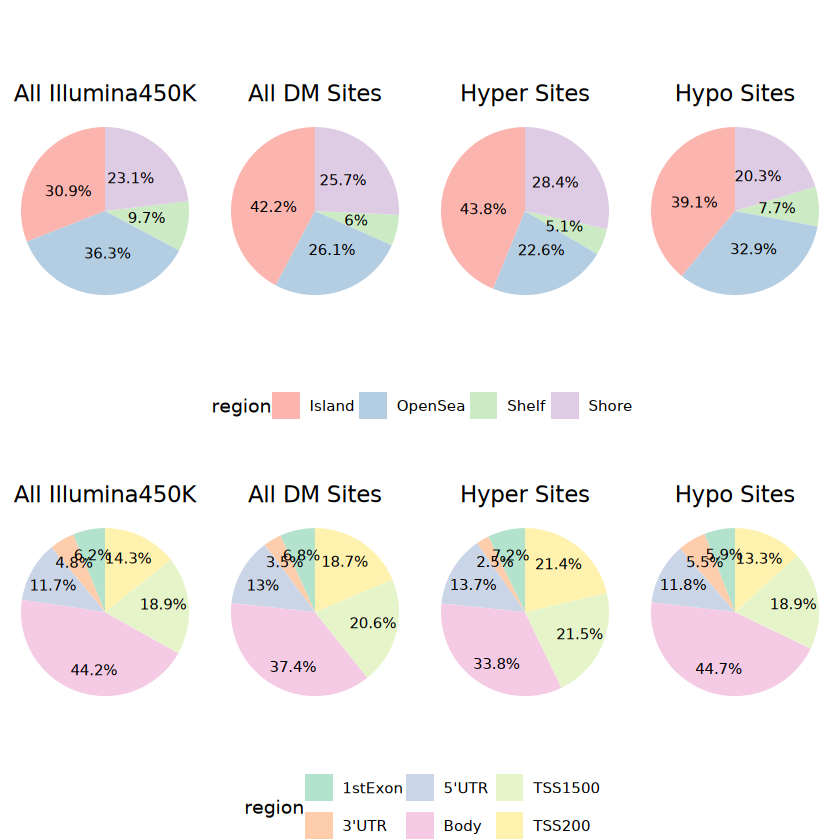

In [40]:
ggarrange(ggarrange(isle_p1,isle_p2,isle_p3,isle_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          ggarrange(region_p1,region_p2,region_p3,region_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          nrow = 2)

In [45]:
isle_df = read.csv("gene_isle_unnormalized_data_remove_crosshyb.csv")
colnames(isle_df)[3] = 'Isle'
region_df = read.csv("gene_region_unnormalized_data_remove_crosshyb.csv")
colnames(region_df)[3] = 'Region'

isle_p1 = ggplot(isle_df[isle_df$df=='Illumina450K',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


isle_p2 = ggplot(isle_df[isle_df$df=='All DM Sites',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p3 = ggplot(isle_df[isle_df$df=='Hypermethylation',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p4 = ggplot(isle_df[isle_df$df=='Hypomethylation',], aes(x = '', y = value, fill = Isle))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

library(ggpubr)


region_p1 = ggplot(region_df[region_df$df=='Illumina450K',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


region_p2 = ggplot(region_df[region_df$df=='All DM Sites',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p3 = ggplot(region_df[region_df$df=='Hypermethylation',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p4 = ggplot(region_df[region_df$df=='Hypomethylation',], aes(x = '', y = value, fill = Region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

png('nocross_hyb_pie_no_anno.png',width=6,height=6,unit='in',res=300)
ggarrange(ggarrange(isle_p1,isle_p2,isle_p3,isle_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          ggarrange(region_p1,region_p2,region_p3,region_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          nrow = 2)
dev.off()

png 
  2

In [113]:
count_isle_450kall = table(anno$Relation_to_Island)
count_isle_dm = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$Relation_to_Island)
count_isle_hyper = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$Relation_to_Island)
count_isle_hypo = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$Relation_to_Island)
count_isle_df = as.data.frame(rbind(count_isle_450kall,count_isle_dm,count_isle_hyper,count_isle_hypo))
count_isle_df$Shore = count_isle_df$N_Shore+count_isle_df$S_Shore
count_isle_df$Shelf = count_isle_df$N_Shelf+count_isle_df$S_Shelf
rownames(count_isle_df) = c('Illumina450K','DM','Hypermethylation','Hypomethylation')
count_isle_final = count_isle_df[,c('Shelf','Shore','Island','OpenSea')]
count_isle_final <- count_isle_final %>% rownames_to_column("df")
count_isle_long <- count_isle_final %>% pivot_longer(cols = -df, names_to = "region", values_to = "value" )
colnames(count_isle_long) = c('df','Isle','Count')

In [112]:
observed1 = cbind(count_isle_long[count_isle_long$df=='Illumina450K','Count'],count_isle_long[count_isle_long$df=='DM','Count'])
chisq.test(observed1)
observed2 = cbind(count_isle_long[count_isle_long$df=='Illumina450K','Count'],count_isle_long[count_isle_long$df=='Hypermethylation','Count'])
chisq.test(observed2)
observed3 = cbind(count_isle_long[count_isle_long$df=='Illumina450K','Count'],count_isle_long[count_isle_long$df=='Hypomethylation','Count'])
chisq.test(observed3)
observed4 = cbind(count_isle_long[count_isle_long$df=='Hypermethylation','Count'],count_isle_long[count_isle_long$df=='Hypomethylation','Count'])
chisq.test(observed4)


	Pearson's Chi-squared test

data:  observed1
X-squared = 1098.8, df = 3, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  observed2
X-squared = 1109.4, df = 3, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  observed3
X-squared = 174.21, df = 3, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  observed4
X-squared = 200.63, df = 3, p-value < 2.2e-16


In [117]:
count_region_450kall = table(anno$UCSC_RefGene_Group)
count_region_dm = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dm=='DM',]$UCSC_RefGene_Group)
count_region_hyper = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hyper',]$UCSC_RefGene_Group)
count_region_hypo = table(cobre_limma_all_nocroshyb_anno[cobre_limma_all_nocroshyb_anno$dir=='Hypo',]$UCSC_RefGene_Group)
count_region_df = as.data.frame(rbind(count_region_450kall,count_region_dm,count_region_hyper,count_region_hypo))
rownames(count_region_df) = c('Illumina450K','DM','Hypermethylation','Hypomethylation')
count_region_final <- count_region_df %>% rownames_to_column("df")
count_region_long <- count_region_final %>% pivot_longer(cols = -df, names_to = "region", values_to = "value" )
colnames(count_region_long) = c('df','region','Count')

In [118]:
observed1 = cbind(count_region_long[count_region_long$df=='Illumina450K','Count'],count_region_long[count_region_long$df=='DM','Count'])
chisq.test(observed1)
observed2 = cbind(count_region_long[count_region_long$df=='Illumina450K','Count'],count_region_long[count_region_long$df=='Hypermethylation','Count'])
chisq.test(observed2)
observed3 = cbind(count_region_long[count_region_long$df=='Illumina450K','Count'],count_region_long[count_region_long$df=='Hypomethylation','Count'])
chisq.test(observed3)
observed4 = cbind(count_region_long[count_region_long$df=='Hypermethylation','Count'],count_region_long[count_region_long$df=='Hypomethylation','Count'])
chisq.test(observed4)



	Pearson's Chi-squared test

data:  observed1
X-squared = 385.73, df = 5, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  observed2
X-squared = 645.97, df = 5, p-value < 2.2e-16



	Pearson's Chi-squared test

data:  observed3
X-squared = 7.9432, df = 5, p-value = 0.1594



	Pearson's Chi-squared test

data:  observed4
X-squared = 270.96, df = 5, p-value < 2.2e-16


In [120]:
isle_df = read.csv("gene_isle_unnormalized_data_remove_crosshyb.csv")
region_df = read.csv("gene_region_unnormalized_data_remove_crosshyb.csv")


isle_p1 = ggplot(isle_df[isle_df$df=='Illumina450K',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


isle_p2 = ggplot(isle_df[isle_df$df=='All DM Sites',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p3 = ggplot(isle_df[isle_df$df=='Hypermethylation',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

isle_p4 = ggplot(isle_df[isle_df$df=='Hypomethylation',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel1") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p1 = ggplot(region_df[region_df$df=='Illumina450K',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All Illumina450K')+
  theme(plot.title = element_text(hjust = 0.5))


region_p2 = ggplot(region_df[region_df$df=='All DM Sites',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('All DM Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p3 = ggplot(region_df[region_df$df=='Hypermethylation',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hyper Sites')+
  theme(plot.title = element_text(hjust = 0.5))

region_p4 = ggplot(region_df[region_df$df=='Hypomethylation',], aes(x = '', y = value, fill = region))+
  geom_bar(width = 1, stat = "identity")+
  coord_polar("y", start=0)+
  scale_fill_brewer(palette="Pastel2") + theme_void()+
  ggtitle('Hypo Sites')+
  theme(plot.title = element_text(hjust = 0.5))

png('nocross_hyb_pie_no_anno.png',width=6,height=6,unit='in',res=300)
ggarrange(ggarrange(isle_p1,isle_p2,isle_p3,isle_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          ggarrange(region_p1,region_p2,region_p3,region_p4,ncol=4,common.legend = TRUE, legend="bottom"),
          nrow = 2)
dev.off()

png 
  2